In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

In [2]:
'''
Choose your Lib path
'''

try:
    from google.colab import drive

    drive.mount('/content/drive')
    # Google Colab
    LIB_PATH = '/content/drive/MyDrive/UFG/01_teaching/'

except ImportError:
    OS = !uname -m # OS

    if OS[0] == 'x86_64':
        # Laptop / Desktop
        LIB_PATH = '/home/kuntur/Documents'
    elif OS[0] == 'aarch64':
        # Android
        LIB_PATH = '/media/sdcard/Documents/'
    else:
        # Windows / macOS
        LIB_PATH = 'MY_OWN_PATH'

sys.path.append(LIB_PATH)

In [3]:
from lib.myPlotLib import *
from lib.myAudioProcessingLib import *

In [4]:
# Definição de diretórios
SOUND_PATH = '../../notebooks/sounds/' # Pasta de arquivos de som
SOUND_FILE = 'train.wav' # Sinal de entrada

In [4]:
# Carregamos o sinal
x, fs = audioread(os.path.join(SOUND_PATH, SOUND_FILE))

In [5]:
print(x.shape, fs)

(12880,) 8192


In [6]:
play(x, fs)

In [7]:
def COMPLEXmagnitude(z, version='sqrt'):
    if version == 'sqrt':
        '''
        Legnth of z
        '''
        mag = ...
    elif version == 'abs':
        '''
        |z|
        '''
        mag = ...
        
    return mag

def COMPLEXphase(z, version='arctan2', units='rad'):
    if version == 'arctan':
        '''
        arctan
        '''
        phi = ...
    elif version == 'arctan2':
        '''
        arctan2
        '''
        phi = ...
    else:
        '''
        angle
        '''
        phi = ...
    
    if units == 'deg': # graus
        '''
        rad2deg
        '''
        return  ...
        
    return phi

In [8]:
N = 5
n = np.arange(N)[:, np.newaxis] # column vector

A = n @ n.T
print(A)

[[ 0  0  0  0  0]
 [ 0  1  2  3  4]
 [ 0  2  4  6  8]
 [ 0  3  6  9 12]
 [ 0  4  8 12 16]]


In [9]:
def myDFT(x, version='fft'):
    if version == 'signal':
        '''
        Signal interpretation
        '''
        ...
    
    elif version == 'basis':
        '''
        Basis expansion
        '''
        ...
    
    elif version == 'matrix':
        '''
        Matrix-vector multiplication
        '''
        ...
    
    elif version == 'fft':
        '''
        Cooley-Tukey radix-2 DIT FFT
        '''
        N = len(x)
        if not np.log2(N).is_integer():
            raise ValueError('Signal length must be a power of 2')
        if N == 2:
            return np.array(...)
        else:
            Xe = myDFT(..., version='fft')
            Xo = myDFT(..., version='fft')
            basis = ...
            return np.append(Xe + basis[0:N//2] * Xo,
                             Xe - basis[0:N//2] * Xo)
        
    else:
        '''
        Numpy
        '''
        X = ...
    
    return X

In [34]:
def myIDFT(X, version='ifft'):
    if version == 'signal':
        '''
        Signal interpretation
        '''
        ...
    
    elif version == 'basis':
        '''
        Basis expansion
        '''
        ...
    
    elif version == 'matrix':
        '''
        Matrix-vector multiplication
        '''
        ...
    
    elif version == 'v4':
        '''
        Cooley-Tukey radix-2 DIT FFT
        '''
        ...
        
    else:
        '''
        Numpy
        '''
        ...
    
    return x

In [35]:
y = x[:1024]
play(y, fs)

In [36]:
Y1 = myDFT(y, 'v1')
# print(Y1) # DFT de y

In [37]:
print(x.dtype, Y1.dtype, len(y), len(Y1))

float64 complex128 1024 1024


In [38]:
Y2 = myDFT(y, 'v2')

In [39]:
Y3 = myDFT(y, 'v3')

In [40]:
Y4 = myDFT(y, 'fft')

In [41]:
Y5 = myDFT(y)

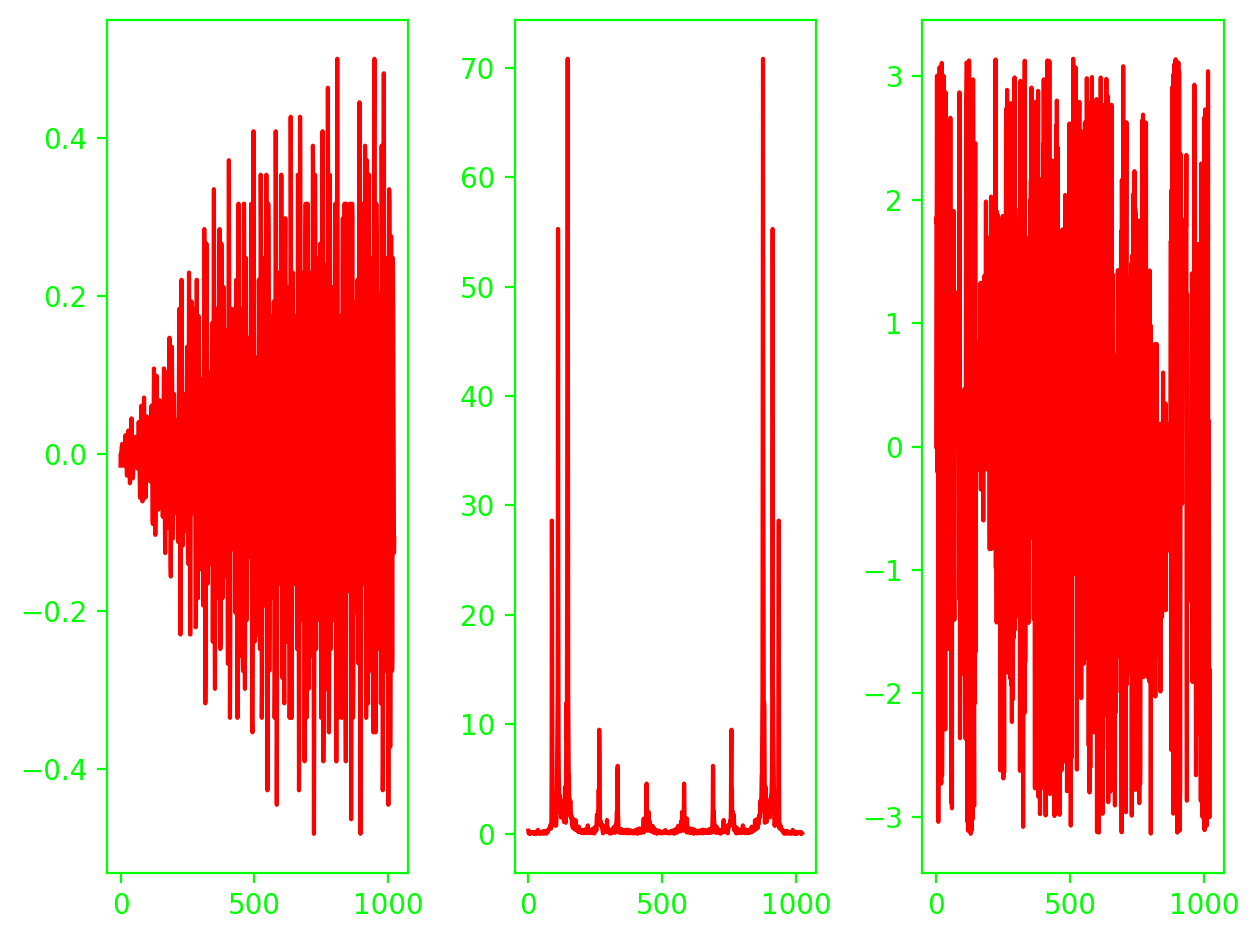

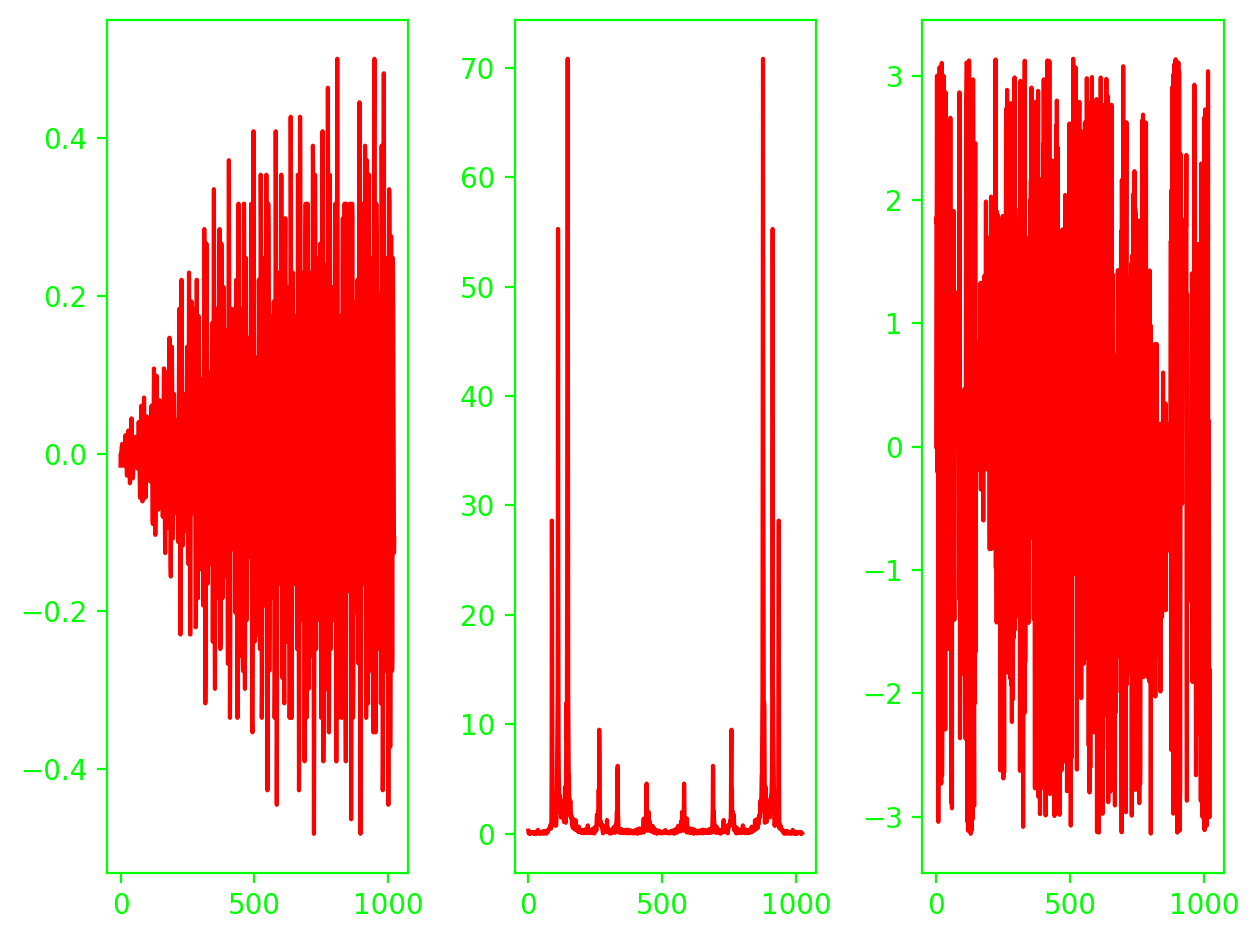

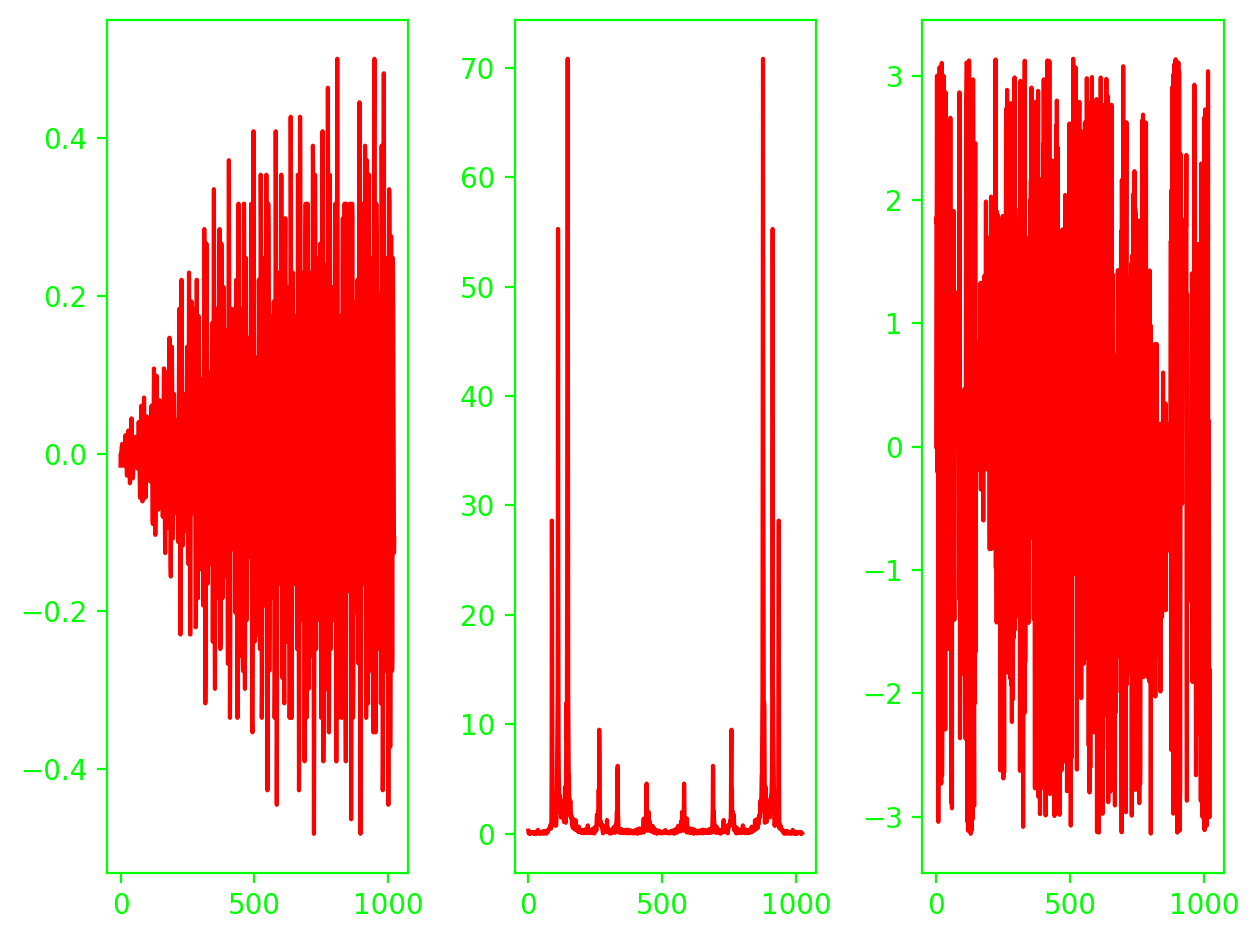

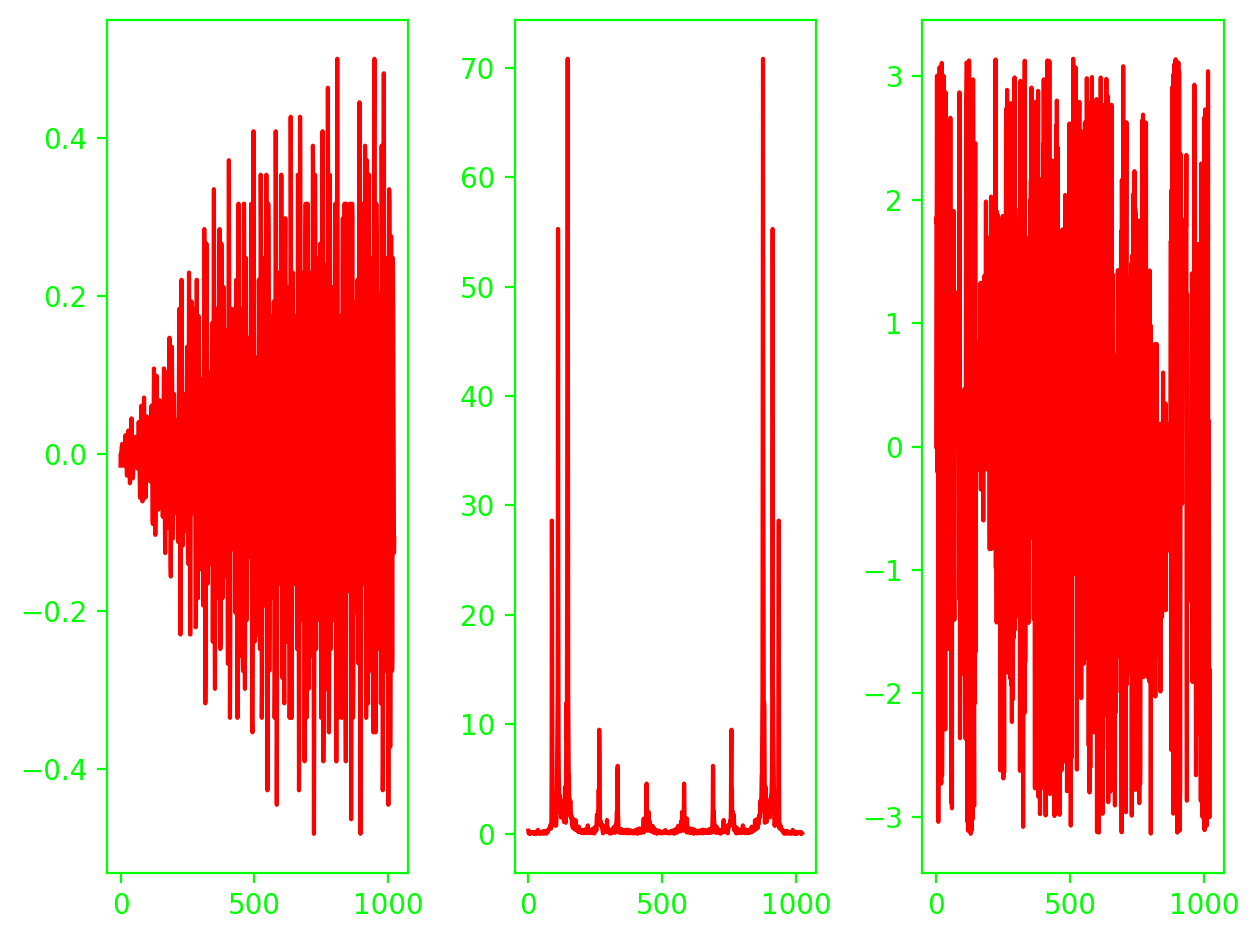

In [42]:
Y1mag = COMPLEXmagnitude(Y1) # Modulo da DFT
Y1pha = COMPLEXphase(Y1) # Fase da DFT

Y2mag = COMPLEXmagnitude(Y2) # Modulo da DFT
Y2pha = COMPLEXphase(Y2) # Fase da DFT

Y3mag = COMPLEXmagnitude(Y3) # Modulo da DFT
Y3pha = COMPLEXphase(Y3) # Fase da DFT

Y4mag = COMPLEXmagnitude(Y4) # Modulo da DFT
Y4pha = COMPLEXphase(Y4) # Fase da DFT

fig, ax = plt.subplots(1, 3)
ax[0].plot(y, 'r')
ax[1].plot(Y1mag, 'r')
ax[2].plot(Y1pha, 'r')
figureFormat(ax, fig, tight=True)
plt.show()

fig, ax = plt.subplots(1, 3)
ax[0].plot(y, 'r')
ax[1].plot(Y2mag, 'r')
ax[2].plot(Y2pha, 'r')
figureFormat(ax, fig, tight=True)
plt.show()

fig, ax = plt.subplots(1, 3)
ax[0].plot(y, 'r')
ax[1].plot(Y3mag, 'r')
ax[2].plot(Y3pha, 'r')
figureFormat(ax, fig, tight=True)
plt.show()

fig, ax = plt.subplots(1, 3)
ax[0].plot(y, 'r')
ax[1].plot(Y4mag, 'r')
ax[2].plot(Y4pha, 'r')
figureFormat(ax, fig, tight=True)
plt.show()


## Synthesis (signal reconstruction)

float64


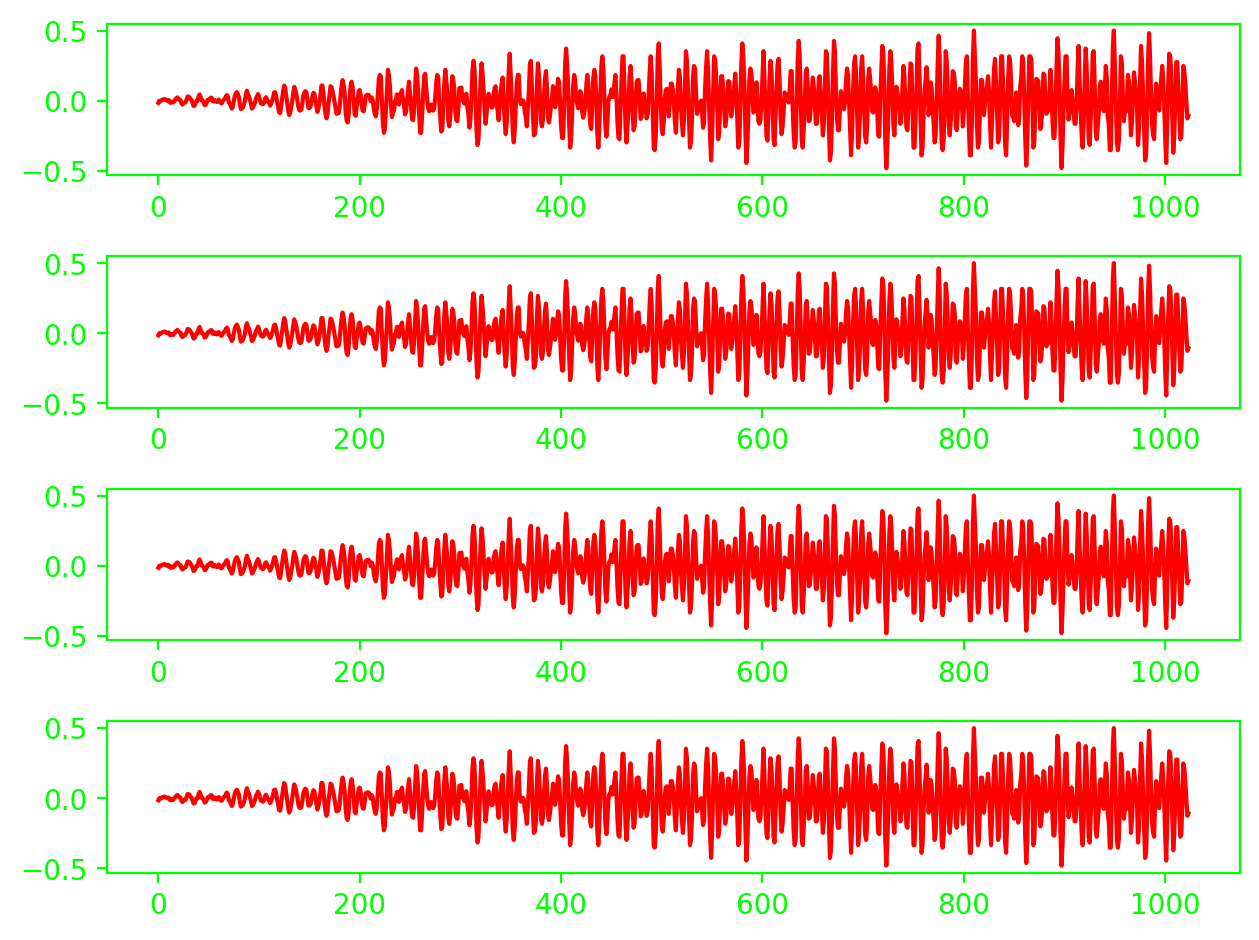

In [44]:
y1 = myIDFT(Y1, 'signal') # sinal reconstruido
y2 = myIDFT(Y2, 'basis') # sinal reconstruido
y3 = myIDFT(Y3, 'matrix') # sinal reconstruido
# y4 = myIDFT(Y4, 'ifft')

print(y1.dtype)

fig, ax = plt.subplots(4, 1)
ax[0].plot(y, 'r')
ax[1].plot(y1, 'r')
ax[2].plot(y2, 'r')
ax[3].plot(y3, 'r')
# ax[4].plot(y4, 'r')
# ax[0].set_ylim([-1, 1])
# ax[1].set_ylim([-1, 1])
figureFormat(ax, fig, tight=True)
plt.show()

Opa, precisamos apenas da metade da informacao das frequencias *DO ESPECTRO*

Plote a metade do espectro do sinal

In [ ]:
N = len(Y1mag)

fig, ax = plt.subplots()
ax.plot(..., 'r')
figureFormat(ax, fig, tight=True)
plt.show()

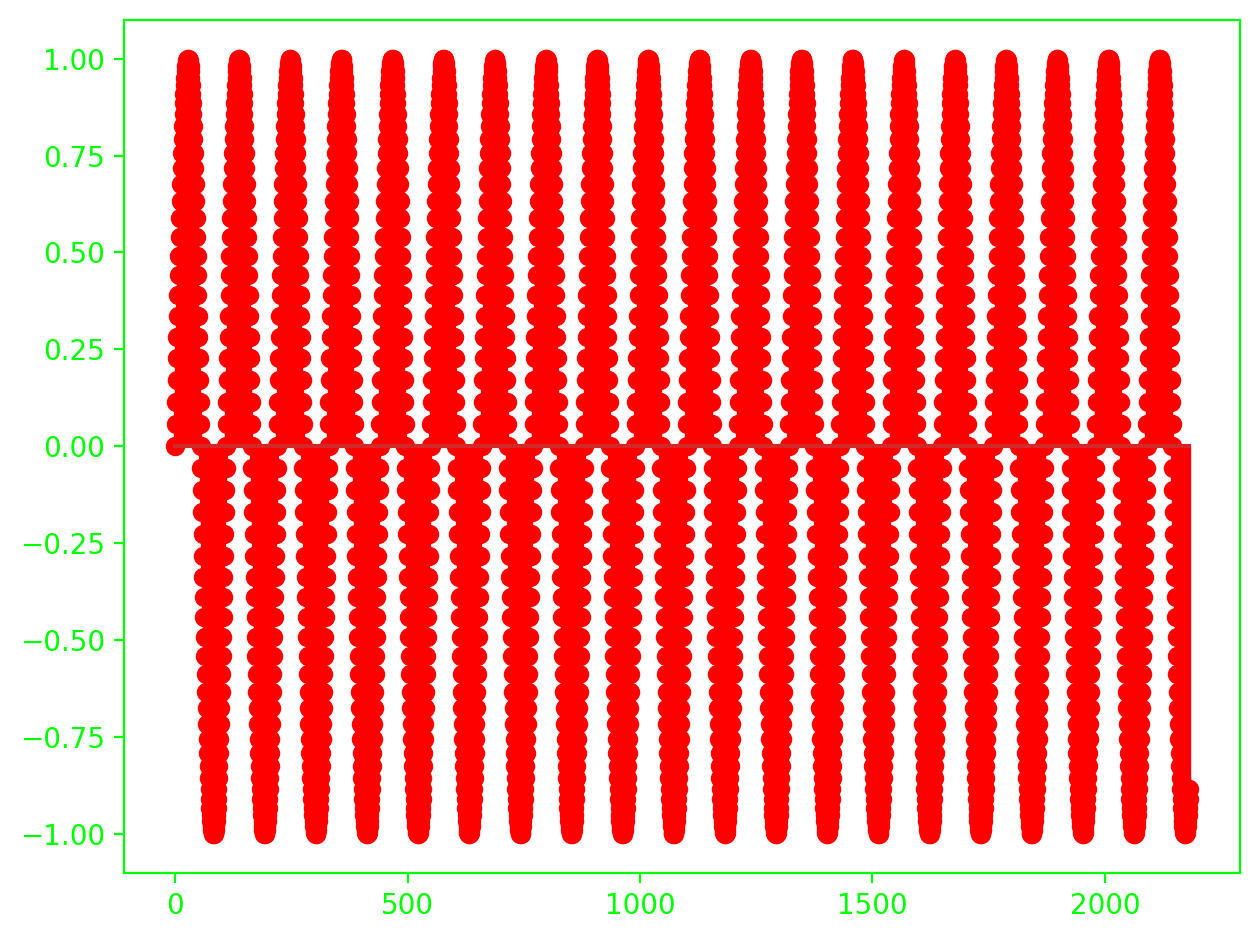

In [163]:
# Plots da DFT para os sinais basicos